In [1]:
import MC
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# metrics_tv.py
#tv distance 
from __future__ import annotations

from dataclasses import dataclass
from typing import Iterable, Optional, Tuple

def tv_distance(p: np.ndarray, q: np.ndarray) -> float:
    """
    Total variation distance: 0.5 * ||p - q||_1.
    p, q are probability vectors of shape (n,).
    """
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    if p.shape != q.shape:
        raise ValueError("p and q must have the same shape.")
    return 0.5 * float(np.sum(np.abs(p - q)))


def worst_case_tv_from_rows(K: np.ndarray, pi: np.ndarray) -> float:
    """
    Given a kernel K (n,n) interpreted as:
      row x = distribution after applying kernel starting from delta_x,
    return max_x TV( row_x(K), pi ).
    """
    K = np.asarray(K, dtype=np.float64)
    pi = np.asarray(pi, dtype=np.float64)
    n = K.shape[0]
    if K.shape != (n, n):
        raise ValueError("K must be square (n,n).")
    if pi.shape != (n,):
        raise ValueError("pi must be shape (n,).")

    # Vectorised: TV(row, pi) = 0.5 * sum_j |K[x,j]-pi[j]|
    return 0.5 * float(np.max(np.sum(np.abs(K - pi[None, :]), axis=1)))


def worst_case_tv_curve(
    P: np.ndarray,
    pi: np.ndarray,
    t_max: int,
    include_t0: bool = True,
    method: str = "iterate",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute the curve:
      d(t) = max_x || delta_x P^t - pi ||_TV   for t=0..t_max.

    Returns (t_values, d_values).

    method:
      - "iterate": build P^t sequentially (stable & fast for moderate n,t_max)
      - "power": compute each P^t via np.linalg.matrix_power (slower if many t)
    """
    P = np.asarray(P, dtype=np.float64)
    pi = np.asarray(pi, dtype=np.float64)

    n = P.shape[0]
    if P.shape != (n, n):
        raise ValueError("P must be square (n,n).")
    if pi.shape != (n,):
        raise ValueError("pi must be shape (n,).")
    if t_max < 0:
        raise ValueError("t_max must be >= 0.")

    if method not in {"iterate", "power"}:
        raise ValueError("method must be 'iterate' or 'power'.")

    t_start = 0 if include_t0 else 1
    t_values = np.arange(t_start, t_max + 1, dtype=int)
    d_values = np.zeros_like(t_values, dtype=np.float64)

    if method == "power":
        for k, t in enumerate(t_values):
            Pt = np.linalg.matrix_power(P, int(t))
            d_values[k] = worst_case_tv_from_rows(Pt, pi)
        return t_values, d_values

    # method == "iterate"
    # We maintain Pt = P^t. For t=0, Pt = I.
    Pt = np.eye(n, dtype=np.float64)

    # If we start from t=1, initialise Pt = P.
    if not include_t0:
        Pt = P.copy()

    for k, t in enumerate(t_values):
        if t == 0:
            # Pt is identity already
            d_values[k] = worst_case_tv_from_rows(Pt, pi)
        else:
            if include_t0:
                # for t>=1, advance Pt each time
                if t == 1:
                    Pt = P.copy()
                else:
                    Pt = Pt @ P
            else:
                # include_t0=False: t_values starts at 1, Pt already P at first step
                if k > 0:
                    Pt = Pt @ P
            d_values[k] = worst_case_tv_from_rows(Pt, pi)

    return t_values, d_values


def mixing_time_upper_bound(
    P: np.ndarray,
    pi: np.ndarray,
    eps: float,
    t_max: int,
) -> Optional[int]:
    """
    Small helper: return the first t <= t_max such that worst-case TV <= eps.
    Returns None if not achieved up to t_max.
    """
    if not (0 < eps < 1):
        raise ValueError("eps must be in (0,1).")
    t, d = worst_case_tv_curve(P, pi, t_max=t_max, include_t0=True, method="iterate")
    idx = np.where(d <= eps)[0]
    return int(t[idx[0]]) if idx.size > 0 else None



In [3]:
def magnetisation(states: np.ndarray) -> np.ndarray:
    return states.sum(axis=1)


def magnetisation_cut_mask(states: np.ndarray) -> np.ndarray:
    """
    Partition:
      S  = {x : m(x) >= 0}
      Sc = {x : m(x) < 0}
    """
    m = magnetisation(states)
    S_mask = (m >= 0)

    # sanity check: avoid trivial partition
    if not S_mask.any() or S_mask.all():
        raise ValueError("Magnetisation cut produced a trivial partition.")

    return S_mask

#mask returns S with all states where magnetisation \geq 0

In [4]:
def check_kernel(K: np.ndarray, pi: np.ndarray, atol: float = 1e-10) -> None:
    if np.any(K < -atol):
        raise ValueError("Kernel has negative entries.")
    if not np.allclose(K.sum(axis=1), 1.0, atol=atol):
        raise ValueError("Rows of kernel do not sum to 1.")
    if not np.allclose(pi @ K, pi, atol=atol):
        raise ValueError("pi is not stationary for the kernel.")


def build_experiment1_kernels(model, alpha: float):
    """
    Build the four kernels for Experiment 1 using the fixed
    magnetisation-sign partition.
    """
    P = model.P
    pi = model.pi
    states = model.states

    S_mask = magnetisation_cut_mask(states)
    G = MC.build_G_from_partition(pi, S_mask)

    kernels = {
        "P": P,
        "GP": G @ P,
        "GPG": G @ P @ G,
        "A_alpha": alpha * P + (1.0 - alpha) * G,
    }

    for name, K in kernels.items():
        check_kernel(K, pi)

    return kernels, S_mask, G


def plot_tv_experiment1(d=4, t_max=15, alpha=0.5):
    """
    Plot worst-case TV curves for:
      P, GP, GPG, A_alpha
    using the fixed magnetisation cut S={m>=0}.
    """
    grid = [(2.0, 0.0), (2.0, 2.0), (15.0, 0.0), (15.0, 2.0)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, (T, h) in zip(axes, grid):
        model = MC.make_curie_weiss_hypercube_model(d=d, T=T, h=h)
        pi = model.pi

        kernels, S_mask, G = build_experiment1_kernels(model, alpha=alpha)

        for label, K in kernels.items():
            t, tv = worst_case_tv_curve(
                K, pi, t_max=t_max, include_t0=True, method="iterate"
            )
            if label == "A_alpha":
                ax.plot(t, tv, marker="o", label=fr"$A_{{\alpha}}$ ($\alpha={alpha}$)")
            else:
                ax.plot(t, tv, marker="o", label=label)

        piS = float(np.sum(pi[S_mask]))
        ax.set_title(f"d={d}, T={T}, h={h}, π(S)={piS:.3f}")
        ax.set_xlabel("t")
        ax.set_ylabel("worst-case TV")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)
    fig.tight_layout(rect=[0, 0.08, 1, 1])
    return fig

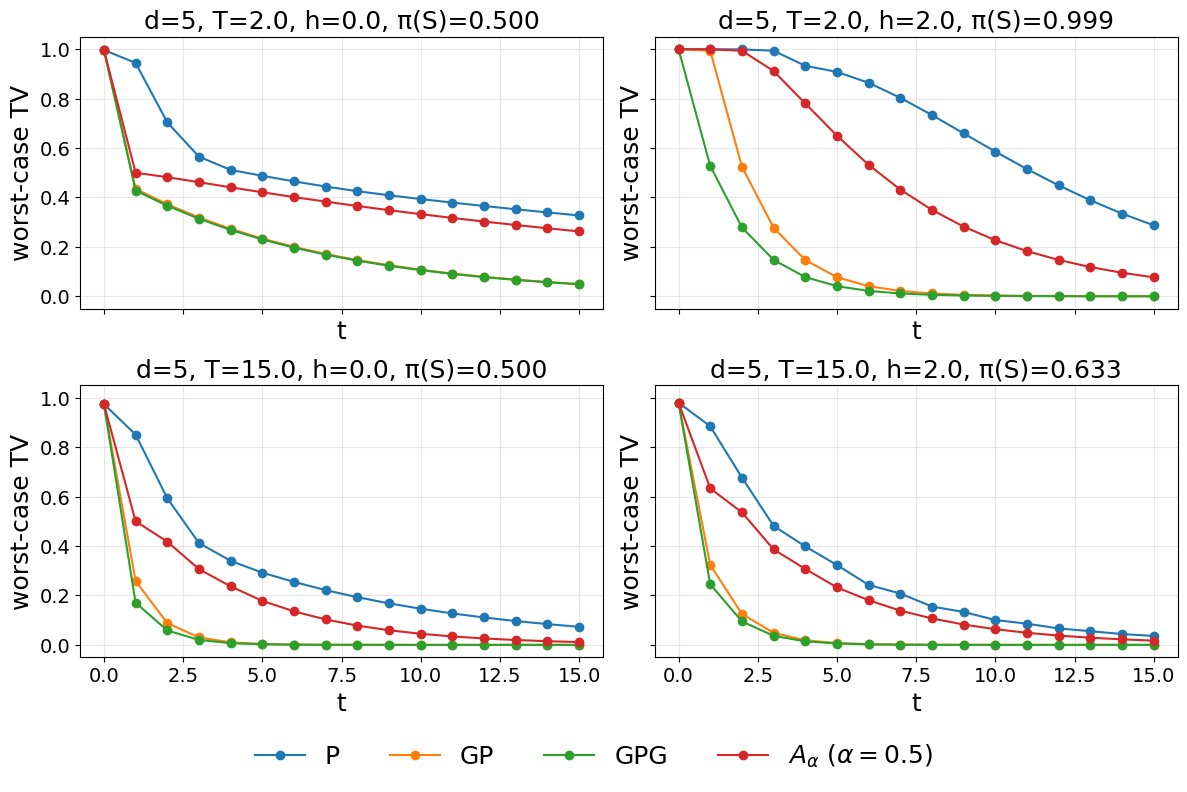

In [5]:
plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

def main():
    # Experiment settings
    d = 5
    t_max = 15
    alpha = 0.5

    # Generate plot
    fig = plot_tv_experiment1(d=d, t_max=t_max, alpha=alpha)

    # Save (optional)
    fname = f"tv_experiment1_d{d}_alpha{alpha}".replace(".", "p")
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")

    # Display
    plt.show()


if __name__ == "__main__":
    main()

In [6]:
def build_Aalpha_kernel(P: np.ndarray, pi: np.ndarray, S_mask: np.ndarray, alpha: float):
    """
    Build A_alpha = alpha P + (1-alpha) G
    for a given partition S_mask.
    """
    P = np.asarray(P, dtype=np.float64)
    pi = np.asarray(pi, dtype=np.float64)
    S_mask = np.asarray(S_mask, dtype=bool)

    G = MC.build_G_from_partition(pi, S_mask)
    K = alpha * P + (1.0 - alpha) * G

    check_kernel(K, pi)
    return K, G

In [7]:
def plot_tv_vs_t_for_alphas(
    d=5,
    t_max=15,
    alphas=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
):
    """
    For each (T,h) panel, plot worst-case TV curves of A_alpha^t
    for several alpha values.
    """
    grid = [(2.0, 0.0), (2.0, 2.0), (15.0, 0.0), (15.0, 2.0)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, (T, h) in zip(axes, grid):
        model = MC.make_curie_weiss_hypercube_model(d=d, T=T, h=h)
        pi = model.pi
        states = model.states
        S_mask = magnetisation_cut_mask(states)
        piS = float(np.sum(pi[S_mask]))

        for alpha in alphas:
            K, _ = build_Aalpha_kernel(model.P, model.pi, S_mask, alpha=float(alpha))
            t, tv = worst_case_tv_curve(
                K, pi, t_max=t_max, include_t0=True, method="iterate"
            )
            ax.plot(t, tv, marker="o", label=fr"$\alpha={alpha}$")

        ax.set_title(f"d={d}, T={T}, h={h}, π(S)={piS:.3f}")
        ax.set_xlabel("t")
        ax.set_ylabel("worst-case TV")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
    fig.tight_layout(rect=[0, 0.08, 1, 1])
    return fig

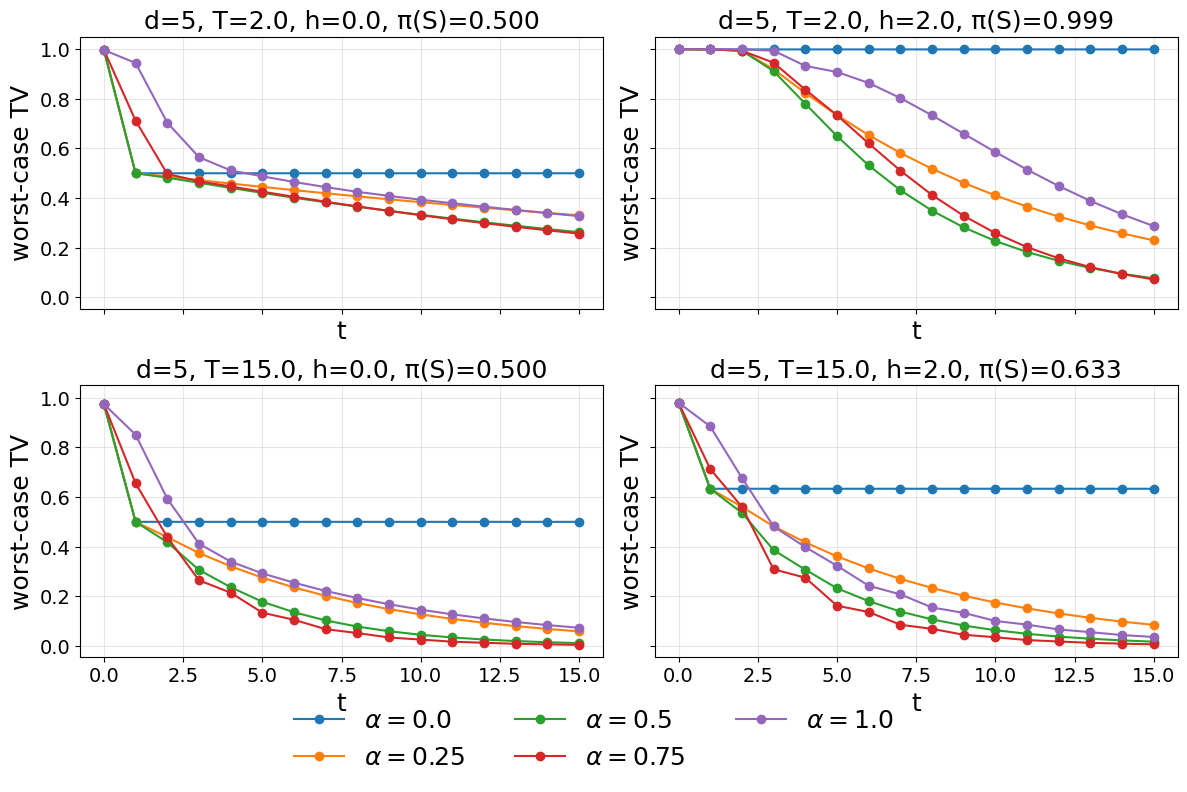

In [8]:
def main_tv_vs_t_alphas():
    d = 5
    t_max = 15
    alphas = (0.0, 0.25, 0.5, 0.75, 1.0)

    fig = plot_tv_vs_t_for_alphas(d=d, t_max=t_max, alphas=alphas)
    fname = f"tv_vs_t_alphas_d{d}".replace(".", "p")
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    main_tv_vs_t_alphas()

In [9]:
def tv_at_time_t0(K: np.ndarray, pi: np.ndarray, t0: int) -> float:
    """
    Return max_x ||delta_x K^t0 - pi||_TV.
    """
    if t0 < 0:
        raise ValueError("t0 must be >= 0.")

    if t0 == 0:
        Kt = np.eye(K.shape[0], dtype=np.float64)
    else:
        Kt = np.linalg.matrix_power(K, t0)

    return worst_case_tv_from_rows(Kt, pi)


def plot_tv_at_fixed_time_vs_alpha(
    d=5,
    alphas=None,
    t_values=(5, 10),
):
    """
    For each (T,h) panel, plot worst-case TV at fixed times t0
    as a function of alpha.
    """
    if alphas is None:
        alphas = np.linspace(0.0, 1.0, 21)

    grid = [(2.0, 0.0), (2.0, 2.0), (15.0, 0.0), (15.0, 2.0)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, (T, h) in zip(axes, grid):
        model = MC.make_curie_weiss_hypercube_model(d=d, T=T, h=h)
    
        P = model.P
        pi = model.pi
        states = model.states
    
        S_mask = magnetisation_cut_mask(states)
        piS = float(np.sum(pi[S_mask]))

        for t0 in t_values:
            vals = []
            for alpha in alphas:
                K, _ = build_Aalpha_kernel(P, pi, S_mask, alpha=float(alpha))
                vals.append(tv_at_time_t0(K, pi, t0=t0))
            ax.plot(alphas, vals, marker="o", label=fr"$t={t0}$")

        ax.set_title(f"d={d}, T={T}, h={h}, π(S)={piS:.3f}")
        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel("worst-case TV")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(t_values), frameon=False)
    fig.tight_layout(rect=[0, 0.08, 1, 1])
    return fig

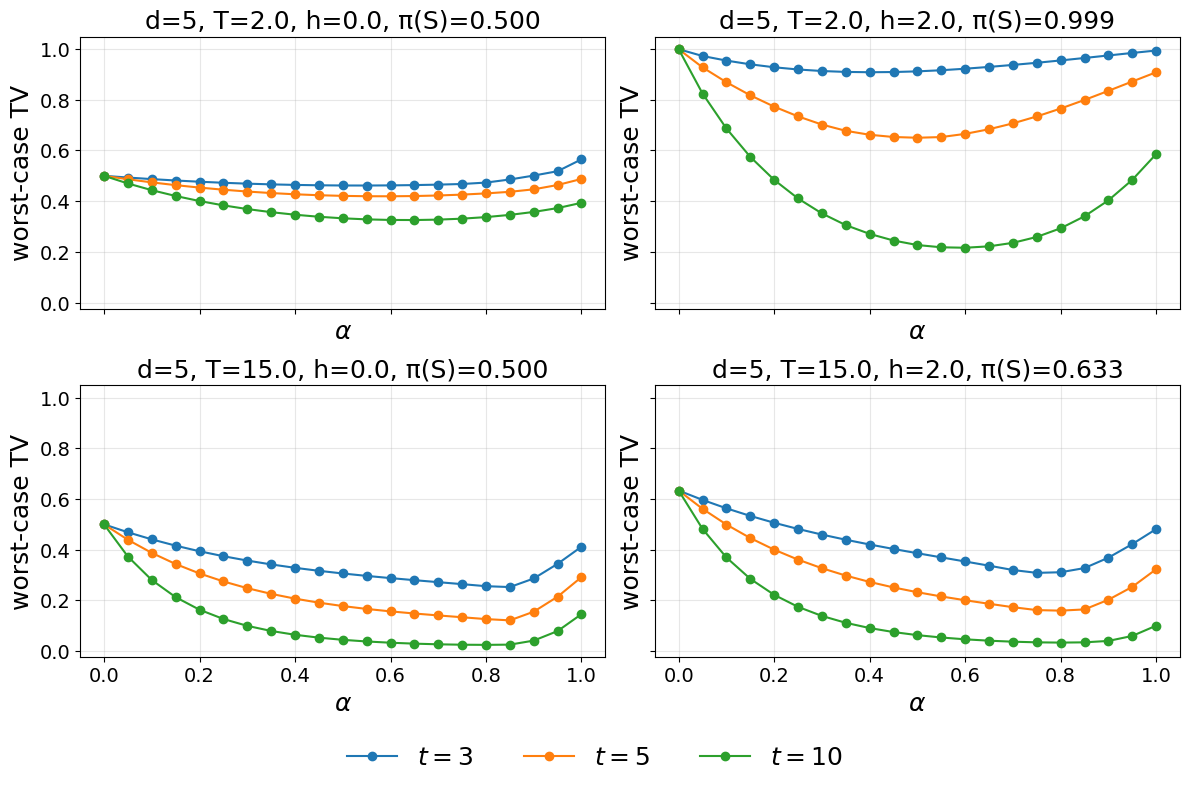

In [10]:
def main_tv_vs_alpha():
    d = 5
    alphas = np.linspace(0.0, 1.0, 21)
    t_values = (3, 5, 10)

    fig = plot_tv_at_fixed_time_vs_alpha(d=d, alphas=alphas, t_values=t_values)
    fname = f"tv_fixedtime_vs_alpha_d{d}".replace(".", "p")
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    main_tv_vs_alpha()

In [15]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, Tuple, Any
import numpy as np


@dataclass
class BestResult:
    S_mask: np.ndarray
    value: float
    aux: Dict[str, Any]


def trace_metric_GP(P: np.ndarray, pi: np.ndarray, S_mask: np.ndarray) -> Tuple[float, Dict[str, Any]]:
    """
    Squared Frobenius objective for GP:
        Tr((GP)^*(GP)) = Tr(PGP)
    """
    G = MC.build_G_from_partition(pi, S_mask)
    val = float(np.trace(P @ G @ P))
    return val, {}


def trace_metric_GPG(P: np.ndarray, pi: np.ndarray, S_mask: np.ndarray) -> Tuple[float, Dict[str, Any]]:
    """
    Squared Frobenius objective for GPG:
        Tr((GPG)^*(GPG)) = Tr(GPGPG)
    """
    G = MC.build_G_from_partition(pi, S_mask)
    K = G @ P @ G
    val = float(np.trace(K @ K))
    return val, {}


def trace_metric_A(P: np.ndarray, pi: np.ndarray, S_mask: np.ndarray) -> Tuple[float, Dict[str, Any]]:
    """
    Squared Frobenius objective for A = 1/2(P + G):
        Tr(A^* A) = 1/4 Tr(P^2 + PG + GP + G)
    """
    G = MC.build_G_from_partition(pi, S_mask)
    val = 0.25 * float(np.trace(P @ P + P @ G + G @ P + G))
    return val, {}


def trace_metric_P(P: np.ndarray) -> float:
    """
    Squared Frobenius objective for P:
        Tr(P^2)
    """
    return float(np.trace(P @ P))


def brute_force_over_cuts(
    P: np.ndarray,
    pi: np.ndarray,
    metrics: Dict[str, Callable[[np.ndarray], Tuple[float, Dict[str, Any]]]],
) -> Dict[str, BestResult]:
    """
    Enumerate all nontrivial 2-block cuts S with the convention 0 in S,
    and minimise each supplied metric over S.
    """
    P = np.asarray(P, dtype=float)
    pi = np.asarray(pi, dtype=float)
    n = pi.shape[0]

    best = {
        name: BestResult(S_mask=np.zeros(n, dtype=bool), value=np.inf, aux={})
        for name in metrics
    }

    full = (1 << n) - 1

    for m in range(1, full):
        if (m & 1) == 0:   # enforce 0 in S to avoid counting complements twice
            continue
        if m == full:
            continue

        S_mask = np.array([(m >> i) & 1 for i in range(n)], dtype=bool)
        if not S_mask.any() or S_mask.all():
            continue

        for name, fn in metrics.items():
            val, aux = fn(S_mask)
            if val < best[name].value:
                best[name] = BestResult(
                    S_mask=S_mask.copy(),
                    value=float(val),
                    aux=aux,
                )

    return best


def optimise_partitions_frobenius(P: np.ndarray, pi: np.ndarray):
    """
    Find the best partition for GP, GPG, and A = 1/2(P+G)
    under the squared Frobenius objective.
    Also return the constant value for P.
    """
    metrics = {
        "GP":  lambda S: trace_metric_GP(P, pi, S),
        "GPG": lambda S: trace_metric_GPG(P, pi, S),
        "A":   lambda S: trace_metric_A(P, pi, S),
    }

    best = brute_force_over_cuts(P, pi, metrics)
    P_val = trace_metric_P(P)

    return {
        "P": {
            "value": P_val,
            "S_mask": None,
        },
        "GP": best["GP"],
        "GPG": best["GPG"],
        "A": best["A"],
    }




In [16]:
def check_kernel(K: np.ndarray, pi: np.ndarray, atol: float = 1e-10) -> None:
    if np.any(K < -atol):
        raise ValueError("Kernel has negative entries.")
    if not np.allclose(K.sum(axis=1), 1.0, atol=atol):
        raise ValueError("Rows of kernel do not sum to 1.")
    if not np.allclose(pi @ K, pi, atol=atol):
        raise ValueError("pi is not stationary for the kernel.")


def build_experiment3_kernels(model):
    """
    Build P, GP, GPG, and A=1/2(P+G) using the Frobenius-optimal
    partition for each partition-dependent sampler.
    """
    P = model.P
    pi = model.pi

    best = optimise_partitions_frobenius(P, pi)

    S_GP = best["GP"].S_mask
    S_GPG = best["GPG"].S_mask
    S_A = best["A"].S_mask

    G_GP = MC.build_G_from_partition(pi, S_GP)
    G_GPG = MC.build_G_from_partition(pi, S_GPG)
    G_A = MC.build_G_from_partition(pi, S_A)

    kernels = {
        "P": P,
        "GP": G_GP @ P,
        "GPG": G_GPG @ P @ G_GPG,
        "A": 0.5 * (P + G_A),
    }

    for _, K in kernels.items():
        check_kernel(K, pi)

    cuts = {
        "GP": S_GP,
        "GPG": S_GPG,
        "A": S_A,
    }

    return kernels, cuts, best

In [24]:
def plot_tv_experiment3(d=5, t_max=15):
    """
    Plot worst-case TV curves for:
      P, GP, GPG, A=1/2(P+G)
    where GP, GPG, and A each use their own Frobenius-optimal cut.
    """
    grid = [(2.0, 0.0), (2.0, 2.0), (15.0, 0.0), (15.0, 2.0)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, (T, h) in zip(axes, grid):
        model = MC.make_curie_weiss_hypercube_model(d=d, T=T, h=h)
        pi = model.pi

        kernels, cuts, best = optimise_partitions_frobenius(model)

        for label, K in kernels.items():
            t, tv = worst_case_tv_curve(
                K, pi, t_max=t_max, include_t0=True, method="iterate"
            )
            if label == "A":
                ax.plot(t, tv, marker="o", label=fr"$A_{{\alpha}}$ ($\alpha=0.5$)")
            else:
                ax.plot(t, tv, marker="o", label=label)

        piS_GP = float(np.sum(pi[cuts["GP"]]))
        piS_GPG = float(np.sum(pi[cuts["GPG"]]))
        piS_A = float(np.sum(pi[cuts["A"]]))

        ax.set_title(
            f"d={d}, T={T}, h={h}"
        )
        ax.set_xlabel("t")
        ax.set_ylabel("worst-case TV")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)
    fig.tight_layout(rect=[0, 0.10, 1, 1])
    return fig

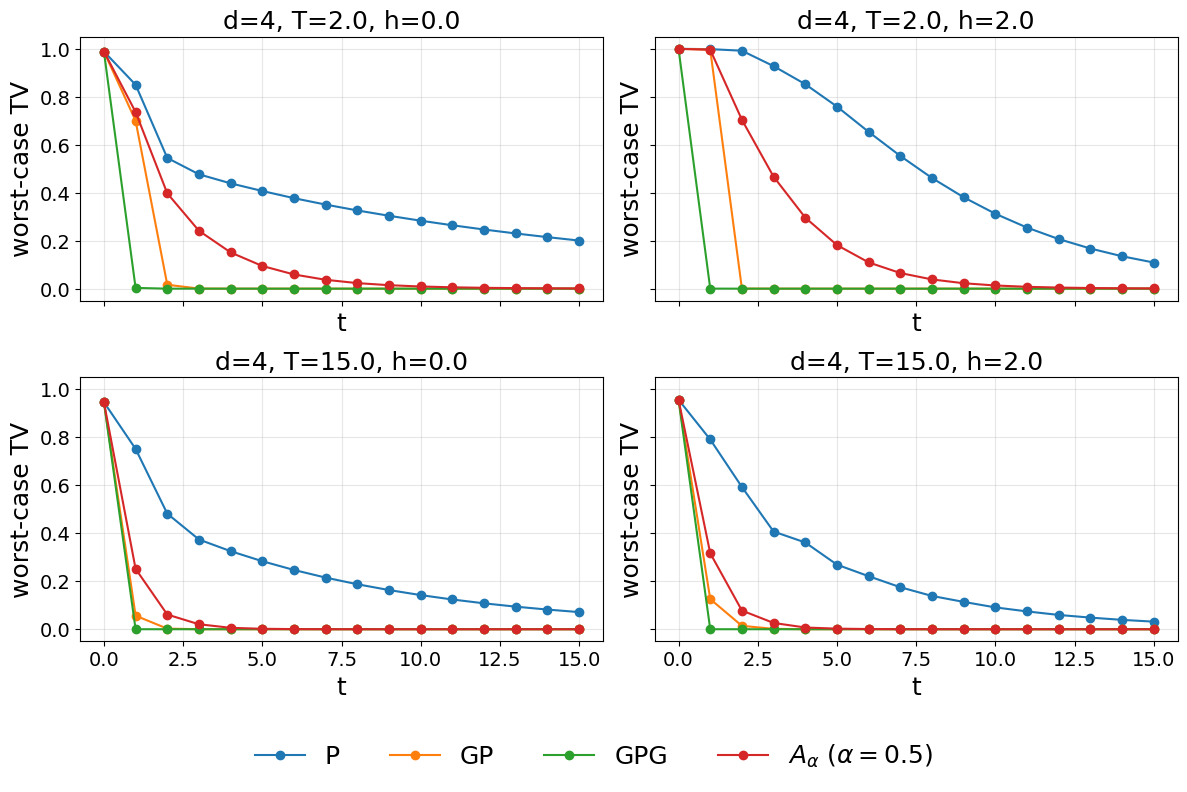

In [25]:
def main_tv_experiment3():
    d = 4
    t_max = 15

    fig = plot_tv_experiment3(d=d, t_max=t_max)
    fname = f"tv_experiment3_optcuts_d{d}".replace(".", "p")
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main_tv_experiment3()

In [34]:
def canonicalise_cut_majority_blue(pi: np.ndarray, S_mask: np.ndarray) -> np.ndarray:
    """
    Flip S -> S^c if needed so that pi(S) >= 1/2.
    Ensures the 'π mass in S' (blue) is the majority in plots.
    """
    piS = float(np.sum(pi[S_mask]))
    return S_mask if piS >= 0.5 else ~S_mask


def plot_pi_mass_by_magnetisation(ax, states, pi, S_mask, title):
    m = states.sum(axis=1)
    m_levels = np.sort(np.unique(m))
    x = np.arange(len(m_levels))

    mass_S  = [float(np.sum(pi[S_mask & (m == mv)])) for mv in m_levels]
    mass_Sc = [float(np.sum(pi[(~S_mask) & (m == mv)])) for mv in m_levels]

    ax.bar(x, mass_S, label="π mass in S")
    ax.bar(x, mass_Sc, bottom=mass_S, label="π mass in S'")

    piS = float(np.sum(pi[S_mask]))
    ax.set_title(f"{title}\nπ(S)={piS:.3f}, |S|={int(S_mask.sum())}")
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in m_levels])
    ax.set_xlabel("magnetisation")
    ax.set_ylabel("π-mass")
    ax.grid(True, axis="y", alpha=0.3)

def get_experiment3_optimal_cuts(model):
    """
    Return the Frobenius-optimal cuts for GP, GPG, and A=1/2(P+G).
    """
    P, pi = model.P, model.pi
    best = optimise_partitions_frobenius(P, pi)

    cuts = {
        "GP": best["GP"].S_mask,
        "GPG": best["GPG"].S_mask,
        "A": best["A"].S_mask,
    }
    return cuts, best

def cut_plots_experiment3_for_model(d, T, h, save=True):
    """
    For one (d,T,h), plot the magnetisation profile of the Frobenius-optimal cuts
    for GP, GPG, and A=1/2(P+G).
    """
    model = MC.make_curie_weiss_hypercube_model(d=d, T=T, h=h)
    P, pi, states = model.P, model.pi, model.states

    cuts, best = get_experiment3_optimal_cuts(model)

    cuts_list = [
        (r"Optimal cut for $GP$", cuts["GP"]),
        (r"Optimal cut for $GPG$", cuts["GPG"]),
        (r"Optimal cut for $A_{{\alpha}}$ ($\alpha=0.5$)", cuts["A"]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, (title, S_mask) in zip(axes, cuts_list):
        S_mask_plot = canonicalise_cut_majority_blue(pi, S_mask)
        plot_pi_mass_by_magnetisation(ax, states, pi, S_mask_plot, title)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
    fig.tight_layout(rect=[0, 0.1, 1, 1])

    if save:
        fname = f"optcuts_by_magnetisation_exp3_d{d}_T{T}_h{h}".replace(".", "p")
        fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")

    return fig

def cut_plots_experiment3_all_4_models(d=4, save=True):
    grid = [(2.0, 0.0), (2.0, 2.0), (15.0, 0.0), (15.0, 2.0)]
    figs = []
    for T, h in grid:
        figs.append(cut_plots_experiment3_for_model(d=d, T=T, h=h, save=save))
    return figs

Displaying figure 1


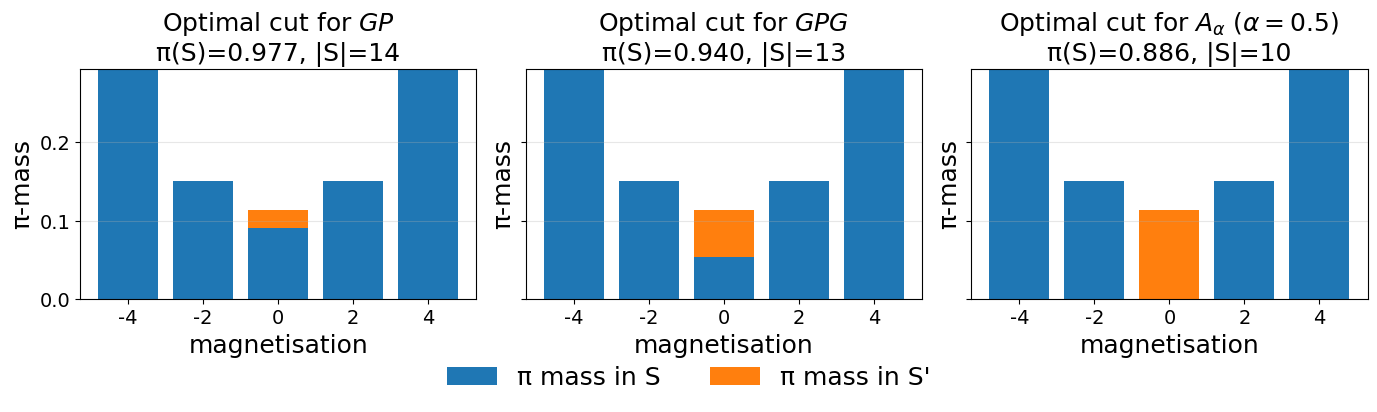

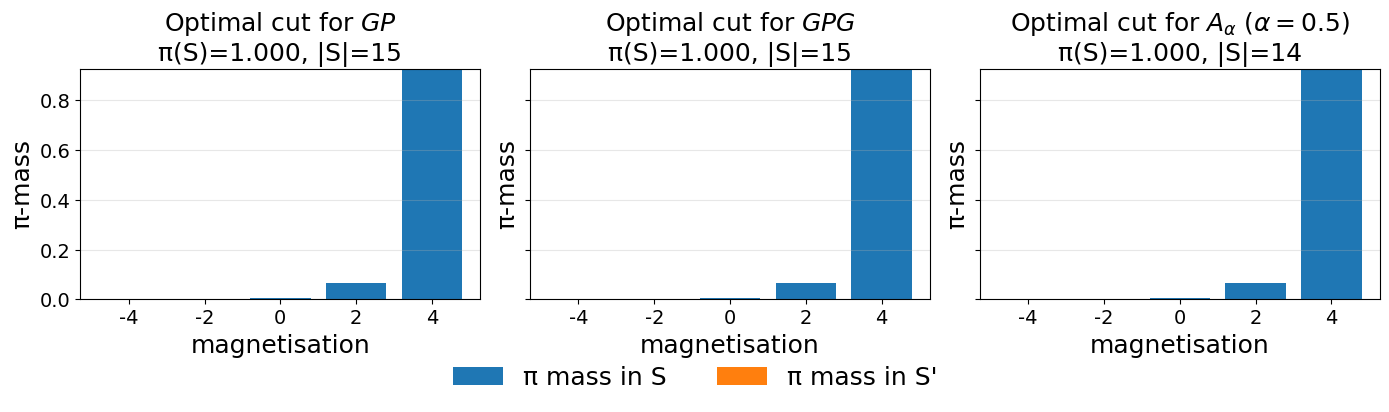

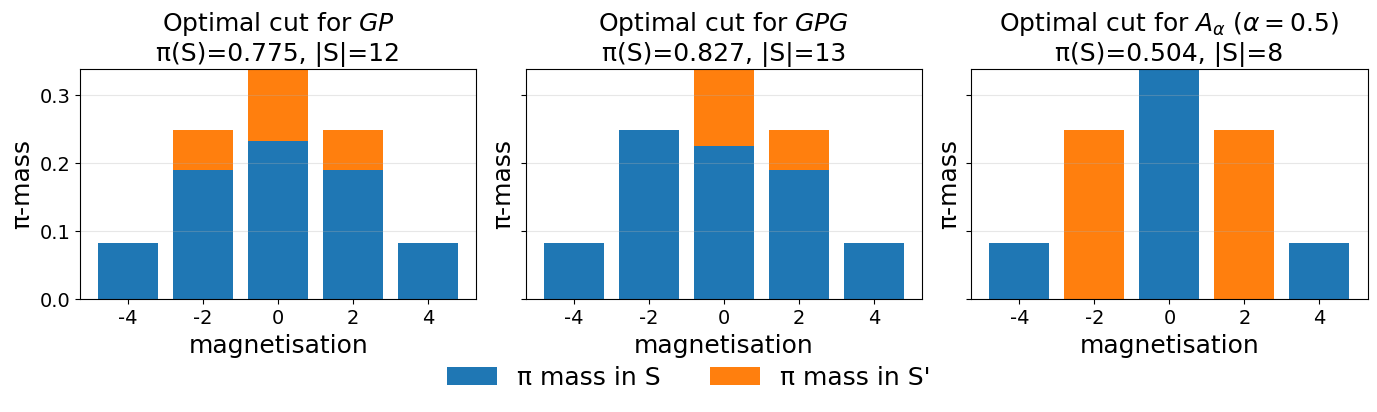

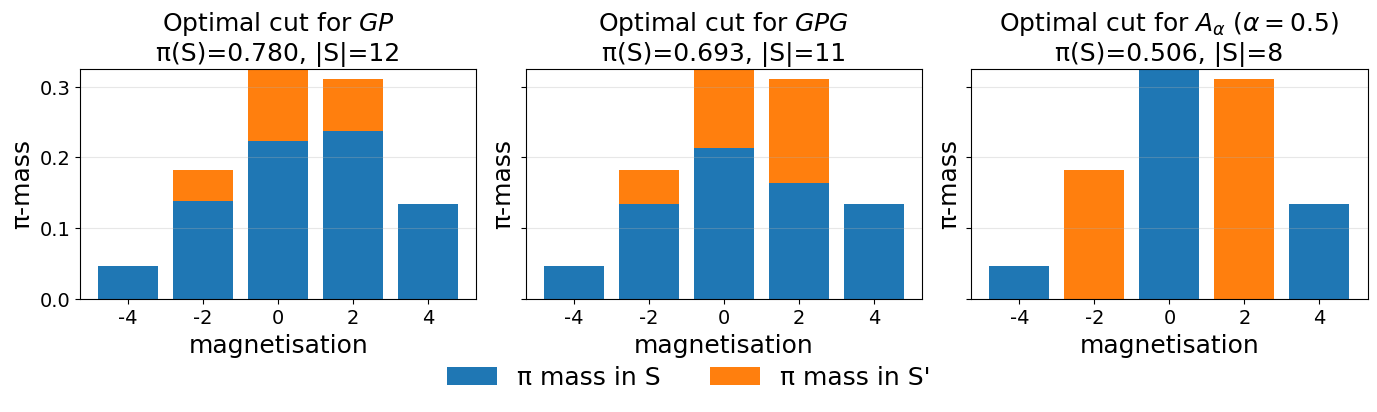

Displaying figure 2
Displaying figure 3
Displaying figure 4


In [35]:
def main_cut_plots_experiment3(d=4, save=True):
    figs = cut_plots_experiment3_all_4_models(d=d, save=save)

    for i, fig in enumerate(figs):
        print(f"Displaying figure {i+1}")
        plt.show()


if __name__ == "__main__":
    main_cut_plots_experiment3()